#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Data Points

In [2]:
#Increment of quarter starting at 2010 Q1 = 1
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 
              28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

#GDP Growth %
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
             1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


#Remove COVID-19 from data
x_covidless = np.delete(x, [13, 14, 15, 16])
y_covidless = np.delete(y, [13, 14, 15, 16])

# Part A
## Cubic Spline Interpolation

#### Cubic Spline Algorithms

In [3]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i]   # Superdiagonal
        D[i - 1] = 6 * ( ( y[i+1]-y[i] )/h[i] - ( y[i]-y[i-1] )/h[i-1]) # Right-hand side vector
        
    return A, B, C, D




def thomas_algorithm(a, b, c, d):
    
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """

    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    M = np.zeros(n)
    M[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        M[i] = (d[i] - c[i] * M[i+1]) / b[i]
    return M




def evaluate_spline(x_interp, x_data, y_data, M):
    h = np.diff(x_data)
    
    # Originally used for loops, but consulted NumPy.org to
    # use np.searchsorted and np.clip instead
    i = np.searchsorted(x_data, x_interp) - 1
    i = np.clip(i, 0, len(x_data) - 2)
        
    dx_left = x_data[i+1] - x_interp
    dx_right = x_interp - x_data[i]
        
    # Cubic Spline Formula
    term1 = (M[i] * (dx_left**3)) / (6 * h[i])
    term2 = (M[i+1] * (dx_right**3)) / (6 * h[i])
    term3 = (y_data[i] - (M[i] * h[i]**2 / 6)) * (dx_left / h[i])
    term4 = (y_data[i+1] - (M[i+1] * h[i]**2 / 6)) * (dx_right / h[i])
        
    piece_poly = term1 + term2 + term3 + term4
        
    return piece_poly

#### Data Interpolation

In [4]:
#For smoothness, x_interp will have values between each quarter
x_interp = np.arange(x.min(), x.max()+0.01, 0.01)

# Utilize above algorithms to create the piecewise polynormials
A, B, C, D = setup_tridiagonal_matrix(x, y)

tridiag_matrix = np.diag(B) + np.diag(A, -1)[:18, :18] + np.diag(C, 1)[:18, :18] #Check condition number
print(f"Spline Condition : {np.linalg.cond(tridiag_matrix):.2e}")

M_out = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x))
M[1:-1] = M_out #removes the endpoints because it's a natural spline

#Evaluate/interpolate with polynomials
y_spline = evaluate_spline(x_interp, x, y, M)
y_point_spline = evaluate_spline(x, x, y, M)

Spline Condition : 7.93e+00


#### Graphed Cubic Spline

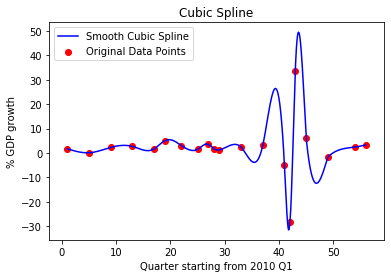

In [5]:
plt.figure()
plt.plot(x_interp, y_spline, label='Smooth Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Original Data Points')

plt.title('Cubic Spline')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('% GDP growth')
plt.legend()
plt.show()

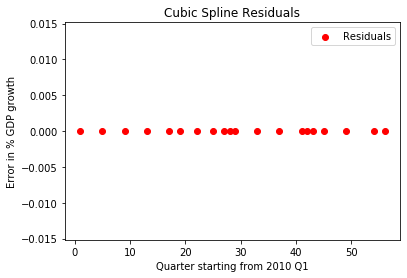

In [6]:
#Residuals
y_spline_residual = y - y_point_spline

plt.scatter(x, y_spline_residual, color='red', label='Residuals')

#Readability
plt.title('Cubic Spline Residuals')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('Error in % GDP growth')
plt.legend()
plt.show()

# Part B
## Polynomial & Least Squares Comparison

#### Polynomial Fit and Least Squares Algorithms

In [7]:
def solve_coefficients(V, y):
    # Find dot products
    VT_V = np.dot(V.T, V)
    VT_Y = np.dot(V.T, y)
    
    #Solve for coefficients
    coefficients = np.linalg.solve(VT_V, VT_Y)

    return coefficients

def vanfit(x, y, coefficients):
    print("Polynomial Coefficients (ascending degree): ", coefficients)

    polynomial = np.poly1d(coefficients[::-1])
    y_poly = polynomial(x_interp)
    y_poly_points = polynomial(x)
    
    return y_poly, y_poly_points







def lstsq(x, y):
    # Stack the design matrix with a column of ones (for the intercept)
    A = np.vstack([x, np.ones(len(x))]).T
    
    print(f"Least Squares Condition: {np.linalg.cond(A):.2f}\n") #condition checker
    
    # Solve using least squares
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    
    y_lstsq = x_interp*m + c #values to be graphed
    y_lstsq_points = x*m + c #to compare with actual values for error evaluation
    
    return y_lstsq, y_lstsq_points, m, c







def analysis(y, y_pred):
    rmse = (np.mean((y - y_pred)**2)**0.5)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    print(f'Root Mean Squared Error: {rmse:.4f}')
    print(f'R-squared: {r_squared:.4f}')

#### Polynomial Fit Approximation and Analysis

In [8]:
degree = 4

V = np.vander(x, N=degree+1, increasing=True) #Create Vandermonde matrix, scale x to lower condition #
print(f"Vandermonde Condition: {np.linalg.cond(V):.2e}") # Check condition

coefficients = solve_coefficients(V, y) #solve for coefficients

y_poly, y_poly_points = vanfit(x, y, coefficients) #approximate data with coefficients

analysis(y, y_poly_points)

Vandermonde Condition: 1.82e+07
Polynomial Coefficients (ascending degree):  [ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]
Root Mean Squared Error: 10.0314
R-squared: 0.0035


#### Polynomial Fit vs Cubic Spline Graph

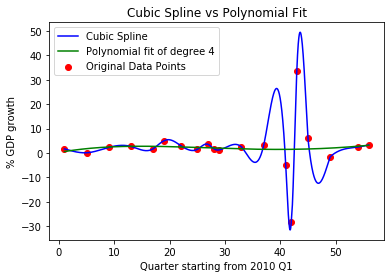

In [9]:
#Original Data, cubic spline, poly fit
plt.scatter(x, y, color='red', label='Original Data Points')
plt.plot(x_interp, y_spline, color='blue', label='Cubic Spline')
plt.plot(x_interp, y_poly, color='green', label=f'Polynomial fit of degree {degree}')

#Readability
plt.title('Cubic Spline vs Polynomial Fit')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('% GDP growth')
plt.legend()
plt.show()

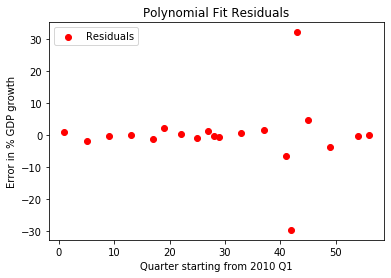

In [10]:
#Residuals
y_poly_residual = y - y_poly_points

plt.scatter(x, y_poly_residual, color='red', label='Residuals')

#Readability
plt.title('Polynomial Fit Residuals')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('Error in % GDP growth')
plt.legend()
plt.show()

#### Polynomial Fit Analysis (No COVID)

In [11]:
degree = 4

V_covidless = np.vander(x_covidless, N=degree+1, increasing=True) #Create Vandermonde matrix
print(f"Vandermonde Condition: {np.linalg.cond(V_covidless):.2e}") # Check condition

coefficients = solve_coefficients(V_covidless, y_covidless) #solve for coefficients
y_poly_covidless, y_poly_points_covidless = vanfit(x_covidless, y_covidless, coefficients) #approximate data with coefficients

analysis(y_covidless, y_poly_points_covidless)

Vandermonde Condition: 1.66e+07
Polynomial Coefficients (ascending degree):  [ 1.53345523e+00 -1.99821150e-01  3.33220755e-02 -1.23821117e-03
  1.28006122e-05]
Root Mean Squared Error: 1.1165
R-squared: 0.4017


#### Polynomial Fit Plot (No COVID)

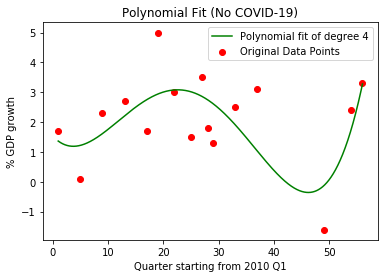

In [12]:
#Original Data, cubic spline, poly fit
plt.scatter(x_covidless, y_covidless, color='red', label='Original Data Points')
plt.plot(x_interp, y_poly_covidless, color='green', label=f'Polynomial fit of degree {degree}')

#Readability
plt.title('Polynomial Fit (No COVID-19)')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('% GDP growth')
plt.legend()
plt.show()

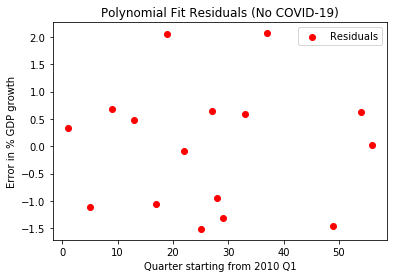

In [13]:
#Residuals
y_poly_residual_covidless = y_covidless - y_poly_points_covidless

plt.scatter(x_covidless, y_poly_residual_covidless, color='red', label='Residuals')

#Readability
plt.title('Polynomial Fit Residuals (No COVID-19)')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('Error in % GDP growth')
plt.legend()
plt.show()

#### Least Squares Approximation and Analysis

In [14]:
#Run algorithm and remember slope and y-intercept
y_lstsq, y_lstsq_points, lstsq_slope, lstsq_offset = lstsq(x_covidless, y_covidless)

print(f"Least Squares Slope: {lstsq_slope:.4f}%, and Intercept: {lstsq_offset:.4f}%")
analysis(y_covidless, y_lstsq_points)

Least Squares Condition: 60.05

Least Squares Slope: -0.0019%, and Intercept: 2.1943%
Root Mean Squared Error: 1.4432
R-squared: 0.0004


#### Least Squares Graph

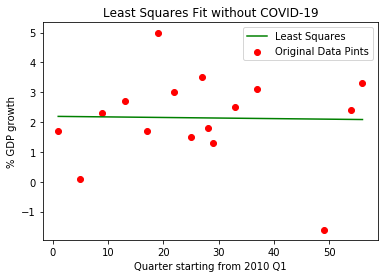

In [15]:
#Original Data, Least squares
plt.scatter(x_covidless, y_covidless, color='red', label='Original Data Pints')
plt.plot(x_interp, y_lstsq, color='green', label=f'Least Squares')

#Readability
plt.title('Least Squares Fit without COVID-19')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('% GDP growth')
plt.legend()
plt.show()

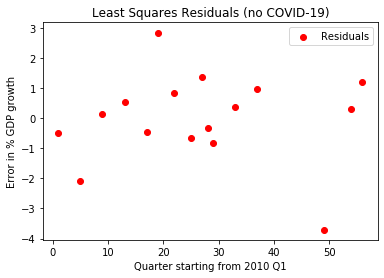

In [16]:
#Residuals
y_lstsq_residual = y_covidless - y_lstsq_points

plt.scatter(x_covidless, y_lstsq_residual, color='red', label='Residuals')

#Readability
plt.title('Least Squares Residuals (no COVID-19)')
plt.xlabel('Quarter starting from 2010 Q1')
plt.ylabel('Error in % GDP growth')
plt.legend()
plt.show()